In [1]:
import os
import math
import shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch


from diffusers import StableDiffusionPipeline
from diffusers import DiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel

In [2]:
# device 설정
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

# 시드 설정 및 생성기 초기화
seed = 12345
generator = torch.Generator(device=device).manual_seed(seed)

# 로컬 경로 설정
project_dir = os.path.join(os.getenv("HOME"), 'workspace', 'projects', 'AIFFEL_quest_rs')
data_dir = os.path.join(project_dir, 'work', 'generative_ai')
os.makedirs(data_dir, exist_ok=True)

device: cuda


In [3]:
def export_as_gif(save_gif_file_path, images, frames_per_second=10, rubber_band=False):
    '''
        save_gif_file_path: 저장할 gif 파일 경로
        images:   만약 numpy 배열이라면, [Image.fromarray(img) for img in images]로 변환
        frames_per_second: fps
        rubber_band: ?
    '''
    if rubber_band:
        images += images[2:-1][::-1]

    images[0].save(
        save_gif_file_path,
        save_all=True,
        append_images=images[1:],
        duration=1000 // frames_per_second,
        loop=0,
    )

def get_local_save_path(filename):
    return os.path.join(data_dir, filename)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

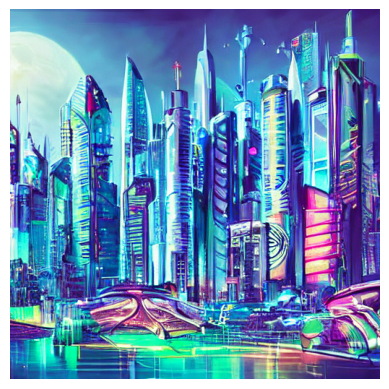

In [4]:
model_id = "CompVis/stable-diffusion-v1-4"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)

prompt = "A futuristic cityscape, vibrant and detailed"
image = pipe(prompt).images[0]

plt.imshow(np.array(image))
plt.axis("off")
plt.show()

In [6]:
# 프롬프트와 보간 단계 수 정의
prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
interpolation_steps = 5

# 토크나이저를 사용해 텍스트를 토큰화합니다.
inputs_1 = pipe.tokenizer(prompt_1, padding="max_length", max_length=pipe.tokenizer.model_max_length, return_tensors="pt")
inputs_2 = pipe.tokenizer(prompt_2, padding="max_length", max_length=pipe.tokenizer.model_max_length, return_tensors="pt")

# CPU에 있는 텐서를 GPU로 이동
inputs_1 = {k: v.to(device) for k, v in inputs_1.items()}
inputs_2 = {k: v.to(device) for k, v in inputs_2.items()}

# 텍스트 인코더를 사용해 프롬프트의 임베딩을 얻습니다.
with torch.no_grad():
    encoding_1 = pipe.text_encoder(**inputs_1).last_hidden_state  # shape: (1, seq_len, emb_dim)
    encoding_2 = pipe.text_encoder(**inputs_2).last_hidden_state

# 배치 차원 제거 (1, seq_len, emb_dim) -> (seq_len, emb_dim)
encoding_1 = encoding_1.squeeze(0)
encoding_2 = encoding_2.squeeze(0)

# 두 인코딩 사이를 선형 보간합니다.
alphas = torch.linspace(0, 1, steps=interpolation_steps, device=encoding_1.device)
# 각 보간 단계마다 encoding_1과 encoding_2의 가중 평균을 계산합니다.
interpolated_encodings = [(1 - alpha) * encoding_1 + alpha * encoding_2 for alpha in alphas]
# 보간 결과를 하나의 텐서로 스택 (shape: (interpolation_steps, seq_len, emb_dim))
interpolated_encodings = torch.stack(interpolated_encodings)

# 임베딩의 shape 출력
print(f"Encoding shape: {encoding_1.shape}")
print(f"interpolated_encodings shape: {interpolated_encodings.shape}")

Encoding shape: torch.Size([77, 768])
interpolated_encodings shape: torch.Size([5, 77, 768])


In [7]:
# 시드 설정 및 생성기 초기화
seed = 12345
generator = torch.Generator(device=device).manual_seed(seed)

# latent 공간 크기: (batch_size, 4, height, width)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

# interpolation_steps 만큼의 노이즈(초기 잠재 변수)를 생성
latents = torch.randn(
    (interpolation_steps, 4, latent_height, latent_width),
    generator=generator,
    dtype=torch.float16,
    device=device
)

# 파이프라인 호출: prompt_embeds에 보간된 텍스트 임베딩을,
# latents에 미리 생성한 노이즈를 전달합니다.
images = pipe(
    prompt_embeds=interpolated_encodings,
    latents=latents,
    generator=generator
).images


  0%|          | 0/50 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


In [ ]:
def export_as_gif(filename, images, frames_per_second=10, rubber_band=False):
    if rubber_band:
        images += images[2:-1][::-1]
    images[0].save(
        filename,
        save_all=True,
        append_images=images[1:],
        duration=1000 // frames_per_second,
        loop=0,
    )

# images는 diffusers 파이프라인에서 생성된 PIL 이미지 리스트라고 가정합니다.
export_as_gif(
    get_local_save_path("doggo-and-fruit-5.gif"),
    images,  # 만약 numpy 배열이라면, [Image.fromarray(img) for img in images]로 변환
    frames_per_second=2,
    rubber_band=True,
)

In [11]:
# 설정
interpolation_steps = 150  # 원래 생성할 샘플 수
batch_size = 3

# interpolated_encodings는 이전에 (interpolation_steps, 77, 768) 모양으로 생성됨
total = interpolated_encodings.shape[0]
num_batches = math.ceil(total / batch_size)
padding_size = num_batches * batch_size - total

if padding_size > 0:
    # 마지막 샘플을 복제해서 패딩 (여기서는 마지막 샘플을 반복)
    pad_encodings = interpolated_encodings[-1:].expand(padding_size, -1, -1)
    interpolated_encodings = torch.cat([interpolated_encodings, pad_encodings], dim=0)

# 이제 전체 샘플 수는 num_batches * batch_size가 됨
batched_encodings = torch.split(interpolated_encodings, batch_size)

# 잠재(latent) 공간의 크기 계산 (일반적으로 512/8 = 64)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

# 각 보간 단계마다 사용할 노이즈(초기 잠재 변수)를 생성합니다.
# noise 텐서의 shape: (interpolation_steps, 4, latent_height, latent_width)
noise = torch.randn(
    (total, 4, latent_height, latent_width),
    generator=generator,
    dtype=torch.float16,
    device=device
)
# noise도 배치 크기의 배수가 아니면 패딩
if padding_size > 0:
    pad_noise = noise[-1:].expand(padding_size, 4, latent_height, latent_width)
    noise = torch.cat([noise, pad_noise], dim=0)

batched_latents = torch.split(noise, batch_size)

# 배치별로 이미지를 생성합니다.
images = []
for i in range(len(batched_encodings)):
    output = pipe(
        prompt_embeds=batched_encodings[i],
        latents=batched_latents[i],
        num_inference_steps=25,
        generator=generator
    )
    images += output.images

# export_as_gif 함수는 이전에 정의한 대로 PIL 이미지 리스트를 GIF로 저장합니다.
export_as_gif(get_local_save_path("doggo-and-fruit-150.gif"), images, rubber_band=True)

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


In [8]:
# 프롬프트 정의
prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
prompt_3 = "The eiffel tower in the style of starry night"
prompt_4 = "An architectural sketch of a skyscraper"

# 보간 관련 설정
interpolation_steps = 6
batch_size = 3
# 총 생성할 임베딩 수: 6 * 6 = 36, 배치 수 = 36 // 3 = 12
batches = (interpolation_steps**2) // batch_size

# 텍스트 인코딩 함수 (diffusers 파이프라인의 tokenizer, text_encoder 사용)
def get_encoding(prompt):
    inputs = pipe.tokenizer(
        prompt,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        return_tensors="pt"
    )
    # GPU에 올리기
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        encoding = pipe.text_encoder(**inputs).last_hidden_state  # shape: (1, seq_len, emb_dim)
    return encoding.squeeze(0).to(device)  # shape: (seq_len, emb_dim)

# 각 프롬프트에 대한 인코딩을 GPU로 가져옵니다.
encoding_1 = get_encoding(prompt_1)
encoding_2 = get_encoding(prompt_2)
encoding_3 = get_encoding(prompt_3)
encoding_4 = get_encoding(prompt_4)

# 1차 보간: encoding_1 ~ encoding_2, encoding_3 ~ encoding_4
alphas = torch.linspace(0, 1, interpolation_steps, device=device)
lin1 = torch.stack([ (1 - alpha) * encoding_1 + alpha * encoding_2 for alpha in alphas ])
lin2 = torch.stack([ (1 - alpha) * encoding_3 + alpha * encoding_4 for alpha in alphas ])

# 2차 보간: lin1 ~ lin2 (결과 shape: (interpolation_steps, interpolation_steps, seq_len, emb_dim))
betas = torch.linspace(0, 1, interpolation_steps, device=device)
interpolated_encodings = torch.stack([ (1 - beta) * lin1 + beta * lin2 for beta in betas ])

# reshape to (interpolation_steps**2, seq_len, emb_dim) => (36, 77, 768)
interpolated_encodings = interpolated_encodings.view(interpolation_steps**2, *lin1.shape[1:])
# 보간된 임베딩을 GPU로 확실히 옮깁니다.
interpolated_encodings = interpolated_encodings.to(device)

# 배치별로 분할 (각 배치에 batch_size개씩)
batched_encodings = torch.split(interpolated_encodings, batch_size)

# 이미지 생성을 위한 latent 공간의 크기 (일반적으로 512/8 = 64)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

images = []
# 각 배치마다 노이즈(초기 잠재 변수)를 생성하고 파이프라인 호출
for batch in batched_encodings:
    current_batch_size = batch.shape[0]
    # latents를 생성할 때도 device, dtype 등이 올바른지 확인합니다.
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 배치의 텍스트 임베딩도 GPU에 있는지 확인 (to(device) 호출)
    batch = batch.to(device)
    output = pipe(
        prompt_embeds=batch,
        latents=latents,
        num_inference_steps=25,
        generator=generator
    )
    images.extend(output.images)  # output.images: PIL 이미지 객체 리스트

# grid를 만들어 이미지를 저장하는 함수
def plot_grid(images, path, grid_size, scale=2):
    fig = plt.figure(figsize=(grid_size * scale, grid_size * scale))
    fig.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.margins(x=0, y=0)
    for row in range(grid_size):
        for col in range(grid_size):
            index = row * grid_size + col
            ax = plt.subplot(grid_size, grid_size, index + 1)
            ax.imshow(np.array(images[index]))
            ax.axis("off")
            plt.margins(x=0, y=0)
    plt.savefig(fname=path, pad_inches=0, bbox_inches="tight", transparent=False, dpi=60)
    plt.close(fig)

# grid_size는 interpolation_steps (6)
plot_grid(images, get_local_save_path("4-way-interpolation.jpg"), interpolation_steps)

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

...

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

In [14]:
images = []
for batch in range(batches):
    batch_encodings = batched_encodings[batch]  # shape: (batch_size, seq_len, emb_dim)
    current_batch_size = batch_encodings.shape[0]
    # 각 배치마다 새로운 노이즈(잠재 변수)를 생성합니다.
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 파이프라인 호출: 텍스트 임베딩(prompt_embeds)와 노이즈(latents)를 전달합니다.
    output = pipe(
        prompt_embeds=batch_encodings,
        latents=latents,
        num_inference_steps=25,
        generator=generator
    )
    images.extend(output.images)  # output.images는 PIL 이미지 객체 리스트

# plot_grid 함수는 PIL 이미지 리스트를 받아 grid로 저장합니다.
plot_grid(images, get_local_save_path("4-way-interpolation-varying-noise.jpg"), interpolation_steps)

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

In [20]:
# 약 10분 정도 걸립니다.
walk_steps = 150
batch_size = 3
batches = walk_steps // batch_size  # 예: 150 / 3 = 50
step_size = 0.005

# "The Eiffel Tower in the style of starry night" 프롬프트에 대한 텍스트 인코딩 얻기
# get_encoding 함수는 이전에 정의된 함수로, 프롬프트를 토큰화하고 텍스트 인코딩을 반환합니다.
encoding = get_encoding("The Eiffel Tower in the style of starry night")  # shape: (77, 768)

# 각 스텝마다 더할 변화량(delta) 생성
delta = torch.ones_like(encoding) * step_size

# 워크 스텝에 따른 인코딩 리스트 생성 (각 스텝마다 인코딩에 delta를 더함)
walked_encodings = []
for step_index in range(walk_steps):
    # clone()을 사용하여 현재 encoding의 복사본을 저장 (참조가 누적되지 않도록)
    walked_encodings.append(encoding.clone())
    encoding = encoding + delta

# walked_encodings의 shape: (walk_steps, 77, 768)
walked_encodings = torch.stack(walked_encodings)
# 배치 크기(batch_size)로 분할: 총 (150 / 3) = 50개의 배치 생성
batched_encodings = torch.split(walked_encodings, batch_size)

# 이미지 생성
images = []
for batch in batched_encodings:
    current_batch_size = batch.shape[0]
    # 잠재(latent) 공간 크기: (batch_size, 4, latent_height, latent_width)
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 파이프라인 호출: 텍스트 임베딩(prompt_embeds)와 초기 잠재(latents)를 사용하여 이미지를 생성
    output = pipe(
        prompt_embeds=batch,
        latents=latents,
        num_inference_steps=25,
        generator=generator
    )
    images.extend(output.images)  # output.images는 PIL 이미지 객체 리스트

# GIF로 내보내기 (export_as_gif 함수는 이전에 정의된 함수)
export_as_gif(get_local_save_path("eiffel-tower-starry-night.gif"), images, rubber_band=True)



  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


...

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


In [41]:
# 전제: device, generator, pipe, export_as_gif, get_encoding 함수는 이미 정의되어 있다고 가정합니다.
# 예: device = "cuda" if torch.cuda.is_available() else "cpu"

prompt = "An oil paintings of cows in a field next to a windmill in Holland"
# get_encoding 함수는 이전에 정의한 텍스트 인코딩 함수 (출력 shape: (seq_len, emb_dim))
encoding = get_encoding(prompt)  # shape: (77, 768)

walk_steps = 150
batch_size = 3
batches = walk_steps // batch_size  # 150/3 = 50

# 잠재(latent) 공간 크기 설정 (일반적으로 512/8 = 64)
latent_channels = 4
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

# base noise shape: (4, 64, 64)
base_noise_shape = (latent_channels, latent_height, latent_width)

# 두 방향의 난수 노이즈 (dtype는 torch.float64로 생성 후, 나중에 float16로 변환)
walk_noise_x = torch.randn(base_noise_shape, dtype=torch.float64, device=device)
walk_noise_y = torch.randn(base_noise_shape, dtype=torch.float64, device=device)

# walk 스케일 계산: 0~2 사이를 interpolation, 각각 코사인과 사인 적용 (결과 shape: (walk_steps,))
walk_scale_x = torch.cos(torch.linspace(0, 2, walk_steps, device=device) * math.pi)
walk_scale_y = torch.sin(torch.linspace(0, 2, walk_steps, device=device) * math.pi)

# tensordot 대신 broadcasting을 사용: 각 스케일에 대해 base noise 곱하기
# 결과 noise_x, noise_y shape: (walk_steps, 4, 64, 64)
noise_x = walk_scale_x.view(walk_steps, 1, 1, 1) * walk_noise_x
noise_y = walk_scale_y.view(walk_steps, 1, 1, 1) * walk_noise_y

# 최종 노이즈: (walk_steps, 4, 64, 64)
noise = noise_x + noise_y
noise = noise.to(torch.float16)

# 배치 단위로 분할: batched_noise는 길이 batches인 튜플, 각 요소 shape: (batch_size, 4, 64, 64)
batched_noise = torch.split(noise, batch_size, dim=0)

# 이미지 생성
images = []
# 텍스트 인코딩은 shape (77, 768); 배치 처리를 위해 unsqueeze 후 expand하여 (batch_size, 77, 768)로 만듭니다.
encoding_expanded = encoding.unsqueeze(0).to(torch.float16)  # shape: (1, 77, 768)

for batch_noise in batched_noise:
    current_batch_size = batch_noise.shape[0]  # 보통 batch_size와 같음
    prompt_embeds = encoding_expanded.expand(current_batch_size, -1, -1)

    # 파이프라인 호출: prompt_embeds와 해당 배치의 latents를 전달합니다.
    output = pipe(
        prompt_embeds=prompt_embeds,
        latents=batch_noise,
        num_inference_steps=25,
        generator=generator
    )
    # output.images는 PIL 이미지 객체 리스트
    images.extend(output.images)

# GIF로 저장 (export_as_gif 함수는 이전에 정의되어 있다고 가정)
export_as_gif(get_local_save_path("cows.gif"), images)

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


In [ ]:
# !git clone https://github.com/huggingface/diffusers ./diffusers_git
# !cd diffusers_git && git checkout main && cd ..
# !uv pip list | grep diffusers
# requirements.txt는 peft==0.7.0 / torchvision 미고정이라 그대로 설치하면 버전 드리프트가 재발함 -> 충돌 없는 항목만 설치
!uv pip install ftfy tensorboard Jinja2 --quiet
# 현재 고정 시켜놓은 토치 관련 버전: torch==2.7.1 / torchaudio==2.7.1 / torchvision==0.22.1 
# (pyproject 고정)에 맞춰 버전 명시해서 추가
# !uv add "huggingface-hub>=1.23.0" "peft>=0.17.0" bitsandbytes xformers==0.0.31 triton==3.3.1
!accelerate config default
!uv pip install -e ./diffusers_git --no-deps

Using Python 3.11.15 environment at: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv
Resolved 1 package in 643ms                                          
   Building diffusers @ file:///home/ysoh1113/workspace/projects/AIFFEL_quest_rs
   Building diffusers @ file:///home/ysoh1113/workspace/projects/AIFFEL_quest_rs
      Built diffusers @ file:///home/ysoh1113/workspace/projects/AIFFEL_quest_rs
Prepared 1 package in 279ms                                              
Uninstalled 1 package in 26ms
Installed 1 package in 2msev0 (from file:///home/ysoh1113/wo
 - diffusers==0.39.0
 + diffusers==0.40.0.dev0 (from file:///home/ysoh1113/workspace/projects/AIFFEL_quest_rs/GoingDeeper/Generative%20AI/diffusers_git)
Using Python 3.11.15 environment at: /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/.venv
diffusers                 0.40.0.dev0        /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/GoingDeeper/Generative AI/diffusers_git
Resolved 186 packages in 977ms                  

In [ ]:
from huggingface_hub import snapshot_download

local_dir = os.path.join(project_dir, 'GoingDeeper', 'Generative AI', 'diffusers_git', 'examples', 'dreambooth', 'dog')

snapshot_download(
    "diffusers/dog-example",
    local_dir=local_dir, repo_type="dataset",
    ignore_patterns=".gitattributes",
)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'/home/ysoh1113/workspace/projects/AIFFEL_quest_rs/GoingDeeper/Generative AI/diffusers_git/examples/dreambooth/dog'

In [88]:
# diffusers_git 레포의 드림부스 dog 실행
temp_dir = os.path.join(project_dir, 'GoingDeeper', 'Generative AI', 'diffusers_git')
local_dir = os.path.join(project_dir, 'GoingDeeper', 'Generative AI', 'diffusers_git', 'examples', 'dreambooth', 'dog')

script_content = f"""#!/bin/bash
export MODEL_NAME="CompVis/stable-diffusion-v1-4"
export INSTANCE_DIR="{local_dir}"
export CLASS_DIR="{local_dir}"
export OUTPUT_DIR="{temp_dir}/examples/dreambooth/data"

echo "$MODEL_NAME"

accelerate launch "{temp_dir}/examples/dreambooth/train_dreambooth.py" \\
  --pretrained_model_name_or_path="$MODEL_NAME" \\
  --instance_data_dir="$INSTANCE_DIR" \\
  --class_data_dir="$CLASS_DIR" \\
  --output_dir="$OUTPUT_DIR" \\
  --instance_prompt="a photo of sks dog" \\
  --class_prompt="a photo of dog" \\
  --resolution=512 \\
  --train_batch_size=1 \\
  --with_prior_preservation --prior_loss_weight=1.0 \\
  --gradient_accumulation_steps=1 --gradient_checkpointing \\
  --use_8bit_adam \\
  --enable_xformers_memory_efficient_attention \\
  --set_grads_to_none \\
  --learning_rate=2e-6 \\
  --lr_scheduler="constant" \\
  --lr_warmup_steps=0 \\
  --num_class_images=5 \\
  --max_train_steps=100
"""

with open("train_dreambooth.sh", "w") as f:
    f.write(script_content)

print("=3")

=3


In [ ]:
# 약 10분 정도 소요됩니다.
%reset -f

!rm -rf ./diffusers_git/examples/dreambooth/dog/.cache
!sh ./train_dreambooth.sh

print('----'*64)
print('학습 완료!!')

CompVis/stable-diffusion-v1-4
07/24/2026 18:00:40 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: no

07/24/2026 18:00:41 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/CompVis/stable-diffusion-v1-4/resolve/main/tokenizer/config.json "HTTP/1.1 404 Not Found"
07/24/2026 18:00:41 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/CompVis/stable-diffusion-v1-4/resolve/main/tokenizer/config.json "HTTP/1.1 404 Not Found"
07/24/2026 18:00:41 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/CompVis/stable-diffusion-v1-4/resolve/main/tokenizer/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
07/24/2026 18:00:41 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/CompVis/stable-diffusion-v1-4/133a221b8aa7292a167afc5127cb63fb5005638b/tokenizer%2Ftokenizer_config.json "HTTP/1.1 200 OK"
07/24/2026 18:00:41 - INFO 

IOStream.flush timed out


Model weights saved in /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/GoingDeeper/Generative AI/diffusers_git/examples/dreambooth/data/unet/diffusion_pytorch_model.safetensors
Configuration saved in /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/GoingDeeper/Generative AI/diffusers_git/examples/dreambooth/data/scheduler/scheduler_config.json

Writing model shards: 100%|███████████████████████| 1/1 [00:02<00:00,  2.20s/it]
Configuration saved in /home/ysoh1113/workspace/projects/AIFFEL_quest_rs/GoingDeeper/Generative AI/diffusers_git/examples/dreambooth/data/model_index.json
Steps: 100%|███████████| 100/100 [1:02:48<00:00, 37.68s/it, loss=0.446, lr=2e-6]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
학습 완료!!


In [106]:
# %reset -f

# # 의존성 모듈을 삭제 후 다시 설치합니다.
# !uv pip uninstall -y diffusers
# !uv pip install diffusers
import os
from diffusers import DiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel

temp_dir = os.path.join(project_dir, 'GoingDeeper', 'Generative AI', 'diffusers_git')

# huggingface에 미리 등록된 base 모델을 다운로드하여 사용합니다.
model_id = "CompVis/stable-diffusion-v1-4"

# 앞서 학습 코드로 만들어진 파라미터들을 로드합니다.
unet = UNet2DConditionModel.from_pretrained(f"{temp_dir}/examples/dreambooth/data/unet")
text_encoder = CLIPTextModel.from_pretrained(f"{temp_dir}/examples/dreambooth/data/text_encoder")

# stable diffusion 의 전체 파이프라인을 구성해줍니다.
pipeline = DiffusionPipeline.from_pretrained(model_id, unet=unet, text_encoder=text_encoder, dtype=torch.float16)
pipeline.to("cuda")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.39.0",
  "_name_or_path": "CompVis/stable-diffusion-v1-4",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

  0%|          | 0/50 [00:00<?, ?it/s]

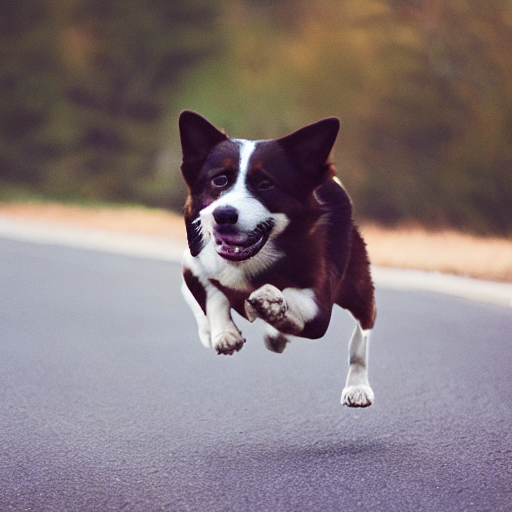

In [107]:
prompt = "A photo of sks dog chasing a car"
image = pipeline(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]

image.save("dog-bucket.png")
image

In [ ]:
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
import torch

pipeline = StableDiffusionPipeline.from_pretrained("digiplay/hellofantasytime_v1.22", torch_dtype=torch.float16)   # 알맞은 모델 ID 를 입력합니다.
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline.to("cuda")

# lora_example.safetensors는 text_encoder 쪽 키에 신/구 명명 방식(lora_linear_layer / to_out_lora)이
# 섞여 있어서, load_lora_weights()의 자동 포맷 변환이 text_encoder 부분에서 rank 정보를 못 찾고
# IndexError를 일으킴. UNet 쪽 키는 정상 변환되므로 UNet에만 로드해서 우회합니다.
state_dict, network_alphas = pipeline.lora_state_dict(f"{data_dir}/lora_example.safetensors", return_alphas=True)
pipeline.load_lora_into_unet(state_dict, network_alphas=network_alphas, unet=pipeline.unet)

In [ ]:
image = pipeline(
    prompt="masterpiece, high quality ,<lora:fat:0.5> pink cat, in a bucket, bokeh background, <lora:add_detail:0.2>",
    negative_prompt="easynegative,(((pubic))), ((((pubic_hair)))),sketch, duplicate, ugly, huge eyes, text, logo, monochrome, worst face, (bad and mutated hands:1.3), (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), crown braid, ((2girl)), (deformed fingers:1.2), (long fingers:1.2),succubus wings,horn,succubus horn,succubus hairstyle,girl,",
    num_inference_steps=28,
    guidance_scale=7,
).images[0]

image.save("sd_lora_sample.png")
image

In [9]:
prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
prompt_3 = "The eiffel tower in the style of starry night"
prompt_4 = "An architectural sketch of a skyscraper"

  0%|          | 0/25 [00:00<?, ?it/s]

Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


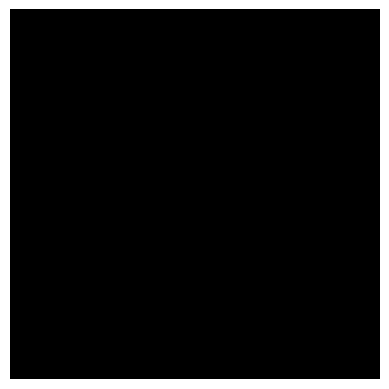

In [10]:
# 4개 프롬프트의 텍스트 인코딩 (get_encoding은 앞서 정의된 함수)
encoding_1 = get_encoding(prompt_1)
encoding_2 = get_encoding(prompt_2)
encoding_3 = get_encoding(prompt_3)
encoding_4 = get_encoding(prompt_4)

# 1차 보간: 각 쌍의 중간점 (alpha=0.5)
mid_12 = 0.5 * encoding_1 + 0.5 * encoding_2
mid_34 = 0.5 * encoding_3 + 0.5 * encoding_4

# 2차 보간: 두 중간점의 중간점 (beta=0.5) -> 4개 프롬프트의 정중앙
center_encoding = 0.5 * mid_12 + 0.5 * mid_34   # shape: (77, 768)

# 배치 차원 추가
center_encoding = center_encoding.unsqueeze(0)  # shape: (1, 77, 768)

# latent 노이즈 생성
latents = torch.randn(
    (1, 4, latent_height, latent_width),
    generator=generator,
    dtype=torch.float16,
    device=device
)

# 이미지 생성
image = pipe(
    prompt_embeds=center_encoding,
    latents=latents,
    num_inference_steps=25,
    generator=generator
).images[0]

plt.imshow(np.array(image))
plt.axis("off")
plt.show()